# Preamble: Solving Linear Equations & Polynomial Regression

This lab builds upon the fundamental mathematical concepts of solving linear equations and applies them to classification problems. Below is a summary of the core mathematical principles from the lecture.

## 1. Matrix Form of Linear Equations
The matrix form of a set of linear equations is defined as:

$$X\vec{B} = \vec{y}$$

Where:
* $X \in \mathbb{R}^{m \times n}$ (The given data/design matrix)
* $\vec{B} \in \mathbb{R}^{n \times 1}$ (The vector containing the unknown variables)
* $\vec{y} \in \mathbb{R}^{m \times 1}$ (The given target values)
* $m$: Number of equations
* $n$: Number of variables

### Case 1: Exact System ($m = n$)
If $X$ is a square matrix of full rank (i.e., no eigenvalue of $X$ is zero $\Leftrightarrow \det(X) \neq 0$), the system has a unique solution:
$$\vec{B} = X^{-1}\vec{y}$$

### Case 2: Overdetermined System ($m > n$)
When there are more equations than variables, the system is typically overdetermined. We seek an optimal vector $\vec{B}^*$ that minimizes the scalar error $||\vec{e}||_2^2$, where $\vec{e} = X\vec{B} - \vec{y}$.

$$\min \sum_{i=1}^{m} e_i^2 = \min_{\vec{B}} \left[ (X\vec{B} - \vec{y})^T (X\vec{B} - \vec{y}) \right]$$
$$= \min_{\vec{B}} \left[ \vec{B}^T X^T X \vec{B} - 2\vec{y}^T X \vec{B} + \vec{y}^T \vec{y} \right] = \min_{\vec{B}} f(\vec{B})$$

To find the minimum, we set the gradient to zero:
$$\nabla f(\vec{B}) = 2(X^T X)\vec{B} - 2X^T\vec{y} \stackrel{!}{=} \vec{0}$$
$$\Rightarrow (X^T X)\vec{B} \stackrel{!}{=} X^T\vec{y}$$

> **Least-Squares Solution:**
> $$\vec{B}^* = (X^T X)^{-1} X^T \vec{y}$$
> Here, $(X^T X)^{-1} X^T$ is the Moore-Penrose pseudoinverse of $X$, denoted as $X^+$.

### Case 3: Underdetermined System ($m < n$)
When there are fewer equations than variables (an ill-posed problem), there are an infinite number of solutions. We select the one with the minimum norm of $\vec{B}$ (a constrained optimization problem):
$$\min_{\vec{B}} (\vec{B}^T\vec{B}) \quad \text{subject to} \quad X\vec{B} = \vec{y}$$
> **Minimum Norm Solution:**
> $$\vec{B}^* = X^T(XX^T)^{-1}\vec{y}$$

---

## 2. Multivariate Polynomial Regression
We can expand a simple feature vector into a multivariate polynomial. Let $M$ be the number of examples (e.g., pixels) and $N$ be the number of parameters.

$$\vec{y}^T_{1 \times M} = \vec{B}^T_{1 \times N} \cdot W_{N \times M}$$
Where $W = (\vec{w}_1, \vec{w}_2, \dots, \vec{w}_M)$. 

To estimate the parameters, we use the right-hand pseudoinverse (since $M > N$):
$$\vec{B}^T = \vec{y}^T W^+$$

Once the model is trained, the estimated measurement $\hat{y}$ for a new feature vector $\vec{w}$ is calculated as:
$$\hat{y} = \vec{B}^T \vec{w}$$
This minimizes the mean squared error $||\vec{y} - \hat{y}||_2^2$ over all examples.

---

## 3. Classification as Regression (Mare vs. Highland Pixels)
We can treat a classification problem as a regression problem with discrete target values. 

**Feature Expansion [Schürmann, 1996]:** Given 2 features $w_1, w_2$, we can expand this into a 2nd-order polynomial with $N=6$ terms: 
$\{w_1, w_2, w_1^2, w_2^2, w_1w_2, 1\}$
$$\Rightarrow \text{Polynomial: } a w_1^2 + b w_2^2 + c w_1 w_2 + d w_1 + e w_2 + f$$

**Discrete Targets:** 
* `1` for Class 1 (e.g., Mare pixels)
* `2` for Class 2 (e.g., Highland pixels)

**Class Decision Rule:**
Using a decision threshold $T$ (for example, $T = 1.5$):
$$k = \begin{cases} 1 & : \hat{y} \le T \\ 2 & : \hat{y} > T \end{cases}$$

### Evaluating the Classifier (ROC Curve)
By varying the threshold $T$, we alter the tradeoff between:
* **True Positives:** Mare pixels correctly recognized as mare pixels.
* **False Positives:** Highland pixels wrongly classified as mare pixels.

Plotting the *Fraction of True Positives* against the *Fraction of False Positives* yields the **Receiver Operating Characteristics (ROC) curve**, where the ideal classifier sits at the coordinate $(0, 1)$.

In [7]:
import numpy as np
import plotly.express as px
import pandas as pd

## Problem 1: The Math of Least Squares (Overdetermined Systems)

In the lecture, we established that for an overdetermined system ($m > n$, more equations than variables), we cannot find a perfect solution. Instead, we find the optimal vector $\vec{B}^*$ that minimizes the squared error. 

The analytical Least-Squares solution using the Moore-Penrose pseudoinverse is:
$$\vec{B}^* = (X^T X)^{-1} X^T \vec{y}$$

**Your Task:**
1. We have provided a small dataset of $m=5$ measurements and $n=2$ features.
2. Manually compute $\vec{B}^*$ by translating the formula above into `numpy` code. 
   * *Hint: Use `X.T` for transpose, `np.linalg.inv()` for the inverse, and `@` for matrix multiplication.*
3. Compute the same vector using NumPy's built-in pseudoinverse function `np.linalg.pinv()` and verify that your manual calculation is correct.

In [3]:
# 1. The Dataset (5 equations, 2 variables)
# X is our design matrix (m x n), y is our target vector (m x 1)
X = np.array([
    [1.0, 2.0], 
    [1.0, 3.0], 
    [1.0, 4.0], 
    [1.0, 5.0], 
    [1.0, 6.0]
])
y = np.array([3.2, 4.1, 5.0, 5.8, 7.1])

print("Matrix X:\n", X)
print("\nVector y:\n", y)

# ---------------------------------------------------------
# 2. MANUALLY COMPUTE B*
# Formula: B* = (X^T * X)^-1 * X^T * y
# ---------------------------------------------------------

X_transpose = X.T
X_transpose_X = X_transpose @ X
inverse_term = np.linalg.inv(X_transpose_X)

# Final manual calculation of B_star
B_star_manual = inverse_term @ X_transpose @ y

print("\n--- Results ---")
print("Manual B*:", B_star_manual)

# ---------------------------------------------------------
# 3. AUTO COMPUTE B* (Using NumPy's built-in pseudoinverse)
# ---------------------------------------------------------

B_star_auto = np.linalg.pinv(X) @ y

print("Auto B*:  ", B_star_auto)

# Check if they match closely
if np.allclose(B_star_manual, B_star_auto):
    print("\nSuccess! Your manual matrix math matches the built-in solver.")
else:
    print("\nMismatch! Check your matrix multiplications.")

Matrix X:
 [[1. 2.]
 [1. 3.]
 [1. 4.]
 [1. 5.]
 [1. 6.]]

Vector y:
 [3.2 4.1 5.  5.8 7.1]

--- Results ---
Manual B*: [1.24 0.95]
Auto B*:   [1.24 0.95]

Success! Your manual matrix math matches the built-in solver.


## Problem 2: Multivariate Polynomial Regression (Feature Expansion)

Often, a simple straight line (or flat plane) isn't enough to capture the true relationship in our data. As discussed in the lecture notes [Schürmann, 1996], we can solve this by expanding our raw features into a multivariate polynomial. 

If we have $M$ examples with 2 features ($w_1, w_2$), we can expand this into a 2nd-order polynomial with $N=6$ terms:
$\{w_1, w_2, w_1^2, w_2^2, w_1w_2, 1\}$

This transforms our $M \times 2$ matrix into an $M \times 6$ design matrix, allowing us to fit the polynomial equation: 
$$y = a w_1^2 + b w_2^2 + c w_1 w_2 + d w_1 + e w_2 + f$$

**Your Task:**
Write a Python function that takes a raw feature matrix `W` (where column 0 is $w_1$ and column 1 is $w_2$) and returns the expanded $M \times 6$ design matrix.

In [6]:
# 1. A small synthetic dataset of 3 pixels with 2 features each (e.g., Albedo and Elevation)
W_raw = np.array([
    [0.5, 1.2],
    [0.8, 0.9],
    [0.2, 1.5]
])

def expand_features(W):
    """
    Takes an M x 2 matrix and expands it to an M x 6 polynomial matrix.
    Expected column order: [w1, w2, w1^2, w2^2, w1*w2, 1]
    """
    w1 = W[:, 0]
    w2 = W[:, 1]
    
    # Compute the polynomial terms
    w1_sq = w1 ** 2
    w2_sq = w2 ** 2
    w1_w2 = w1 * w2
    
    # Create an array of ones for the bias term 'f' (length M)
    # W.shape[0] gives us 'M', the number of rows/examples
    bias = np.ones(W.shape[0])
    
    # Stack all columns together into an M x 6 matrix
    expanded_W = np.column_stack((w1, w2, w1_sq, w2_sq, w1_w2, bias))
    
    return expanded_W

# Test the function
W_expanded = expand_features(W_raw)

print("Raw Features (M x 2):\n", W_raw)
print("\nExpanded Features (M x 6):\n", W_expanded)

Raw Features (M x 2):
 [[0.5 1.2]
 [0.8 0.9]
 [0.2 1.5]]

Expanded Features (M x 6):
 [[0.5  1.2  0.25 1.44 0.6  1.  ]
 [0.8  0.9  0.64 0.81 0.72 1.  ]
 [0.2  1.5  0.04 2.25 0.3  1.  ]]


## Problem 3: Classification and the ROC Curve 
### (Lunar Pixel Analysis: Mare vs. Highlands)

We can treat a classification problem as a regression problem with discrete target values. Today, we want to classify lunar surface pixels into two categories based on two features: Albedo (brightness) and Elevation. 

* **Class 1 (Mare):** Dark, low-elevation basaltic plains. Target value = `1`.
* **Class 2 (Highland):** Brighter, higher-elevation terrain. Target value = `2`.

**Your Task:**
1. Use your `expand_features` function from Problem 2 to expand the raw lunar pixel data.
2. Use the Least Squares formula (from Problem 1) to train the model and calculate $\vec{B}^*$.
3. Compute the continuous predicted values $\hat{y}$.
4. Implement the class decision rule: $\hat{y} \le T \Rightarrow \text{Class 1 (Mare)}$ and $\hat{y} > T \Rightarrow \text{Class 2 (Highland)}$.
5. Calculate the True Positive Rate and False Positive Rate for 50 different thresholds $T$ to plot the Receiver Operating Characteristic (ROC) curve.

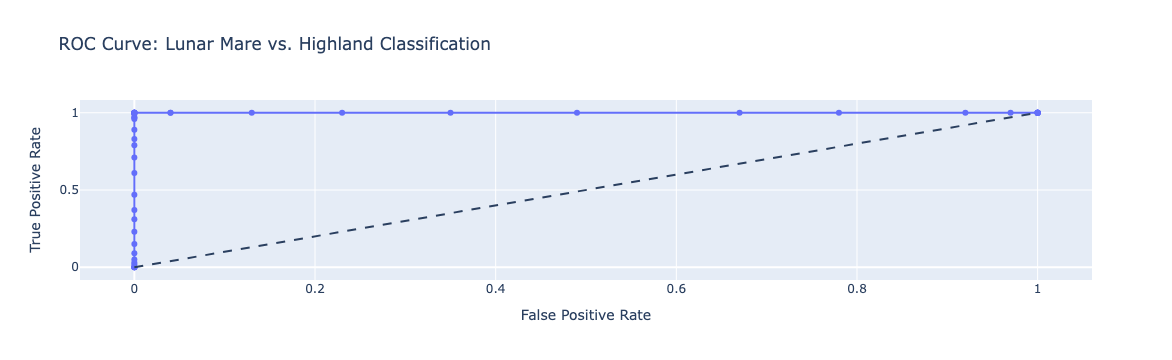

In [8]:
import numpy as np
import plotly.express as px
import pandas as pd

# --- PROVIDED SYNTHETIC LUNAR DATA ---
np.random.seed(42)
# Mare pixels: lower albedo (~0.1), lower elevation (~-2.0 km)
mare_w1 = np.random.normal(0.1, 0.05, 100)
mare_w2 = np.random.normal(-2.0, 0.5, 100)
mare_y = np.ones(100) # Target 1

# Highland pixels: higher albedo (~0.25), higher elevation (~1.5 km)
high_w1 = np.random.normal(0.25, 0.08, 100)
high_w2 = np.random.normal(1.5, 0.8, 100)
high_y = np.full(100, 2) # Target 2

# Combine and shuffle
W_raw = np.vstack((np.column_stack((mare_w1, mare_w2)), np.column_stack((high_w1, high_w2))))
y_true = np.concatenate((mare_y, high_y))

# Step 1 & 2: Feature Expansion & Model Training
W_expanded = expand_features(W_raw)

# Using np.linalg.pinv is the cleanest way here, but they can use the manual formula too
B_star = np.linalg.pinv(W_expanded) @ y_true

# Step 3: Compute continuous predictions (y_hat)
y_hat = W_expanded @ B_star

# Step 4 & 5: Evaluate Thresholds & Calculate ROC metrics
thresholds = np.linspace(0.5, 2.5, 50)
tpr_list = []
fpr_list = []

total_mare = np.sum(y_true == 1)
total_highland = np.sum(y_true == 2)

for T in thresholds:
    # Apply decision rule: np.where(condition, value_if_true, value_if_false)
    predictions = np.where(y_hat <= T, 1, 2)
    
    # Count True Positives (Predicted 1 AND Actually 1)
    tp = np.sum((predictions == 1) & (y_true == 1))
    
    # Count False Positives (Predicted 1 AND Actually 2)
    fp = np.sum((predictions == 1) & (y_true == 2))
    
    tpr_list.append(tp / total_mare)
    fpr_list.append(fp / total_highland)

# --- PROVIDED PLOTTING CODE ---
roc_df = pd.DataFrame({'False Positive Rate': fpr_list, 'True Positive Rate': tpr_list, 'Threshold': thresholds})
fig = px.line(roc_df, x='False Positive Rate', y='True Positive Rate', hover_data=['Threshold'],
              title="ROC Curve: Lunar Mare vs. Highland Classification", markers=True)
fig.add_shape(type='line', line=dict(dash='dash'), x0=0, x1=1, y0=0, y1=1)
fig.show()